In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression, LinearRegression
from xgboost import XGBClassifier, XGBRegressor

# Métricas
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
def specificity_score(y_true, y_pred):
    """Calcula a Especificidade a partir da matriz de confusão."""
    # tn, fp, fn, tp
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    specificity = tn / (tn + fp)
    return specificity

def plot_confusion_matrix(y_true, y_pred, title, filename):
    """Plota e salva a matriz de confusão."""
    plt.figure(figsize=(7, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['NonDemented', 'Demented'],
                yticklabels=['NonDemented', 'Demented'])
    plt.title(title)
    plt.ylabel('Verdadeiro (Actual)')
    plt.xlabel('Predito (Predicted)')
    plt.savefig(f"{filename}.png")
    print(f"Matriz de confusão salva em {filename}.png")

def plot_age_scatterplot(y_true, y_pred, title, filename):
    """Plota e salva o scatterplot de predição de idade."""
    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, s=100)
    # Linha de predição perfeita
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.title(title)
    plt.xlabel('Idade Real (Actual Age)')
    plt.ylabel('Idade Predita (Predicted Age)')
    plt.grid(True)
    plt.savefig(f"{filename}.png")
    print(f"Gráfico de predição de idade salvo em {filename}.png")

def load_data_set(set_name):
    """Carrega e junta os 3 CSVs de um diretório (treino, validacao, teste)."""
    base_dir = f'../database/{set_name}'
    try:
        df_oasis = pd.read_csv(os.path.join(base_dir, 'oasis_longitudinal_demographic.csv'), sep=';', decimal=',')
        df_ids = pd.read_csv(os.path.join(base_dir, 'features_identifiers.csv'), sep=';', decimal=',')
        df_feat = pd.read_csv(os.path.join(base_dir, 'features_full.csv'), sep=';', decimal=',')
        
        # Lista de colunas demográficas/alvo (exceto IDs)
        overlap_cols = [
            'Group', 'Visit', 'MR Delay', 'M/F', 'Hand', 'Age', 'EDUC', 'SES', 
            'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF'
        ]
        
        # Remove colunas sobrepostas de df_ids e df_feat
        # 'Subject ID' também pode sobrepor, então adicionamos
        cols_to_drop_ids = ['Subject ID', 'Group']
        cols_to_drop_feat = [col for col in overlap_cols if col in df_feat.columns]
        
        # Merge 1: df_oasis (demografia) + df_ids (features identificadoras)
        data = pd.merge(
            df_oasis, 
            df_ids.drop(columns=cols_to_drop_ids, errors='ignore'), 
            on='MRI ID', 
            how='inner'
        )
        
        # Merge 2: (oasis+ids) + df_feat (features completas)
        # Garantindo que 'df_feat' não traga colunas demográficas duplicadas
        data = pd.merge(
            data, 
            df_feat.drop(columns=cols_to_drop_feat, errors='ignore'), 
            on='MRI ID', 
            how='inner'
        )
        
        return data
    except FileNotFoundError as e:
        print(f"Erro ao carregar dados de '{set_name}': {e}")
        return None
    except Exception as e:
        print(f"Erro ao processar dados de '{set_name}': {e}")
        return None

In [3]:
# Carrega os três conjuntos de dados
df_train = load_data_set('treino')
df_val = load_data_set('validacao')
df_test = load_data_set('teste')

if df_train is None or df_val is None or df_test is None:
    print("Falha no carregamento dos dados. Verifique os caminhos e os arquivos.")
else:
    print(f"Dados carregados: Treino({df_train.shape}), Validação({df_val.shape}), Teste({df_test.shape})")
    print(f"Colunas disponíveis: {df_train.columns.tolist()}")

Dados carregados: Treino((239, 29)), Validação((58, 29)), Teste((76, 29))
Colunas disponíveis: ['Subject ID_x', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Group_num', 'Ventricle_Area_x', 'Ventricle_Perimeter_x', 'Ventricle_Circularity_x', 'Ventricle_Eccentricity_x', 'Ventricle_Solidity_x', 'Ventricle_MajorAxisLength_x', 'Subject ID_y', 'Ventricle_Area_y', 'Ventricle_Perimeter_y', 'Ventricle_Circularity_y', 'Ventricle_Eccentricity_y', 'Ventricle_Solidity_y', 'Ventricle_MajorAxisLength_y']


Classificação (Demented vs NonDemented)
Tarefa 1 usando 23 features numéricas e 1 categóricas.

--- Treinando Modelo: Regressão Logística ---
Buscando melhor C (hiperparâmetro) no conjunto de validação...
Melhor C encontrado: 0.01 (Score de Validação: 1.0000)
Treinando modelo final com Treino+Validação...

--- Métricas (Regressão Logística) no Conjunto de Teste ---
Acurácia:     1.0000
Sensibilidade: 1.0000 (Recall - Taxa de 'Demented' corretos)
Especificidade: 1.0000 (Taxa de 'NonDemented' corretos)
Matriz de confusão salva em out/cm_lr.png

--- Métricas (XGBoost Classifier) no Conjunto de Teste ---
Acurácia:     1.0000
Sensibilidade: 1.0000 (Recall)
Especificidade: 1.0000 (Specificity)
Matriz de confusão salva em out/cm_xgb_c.png


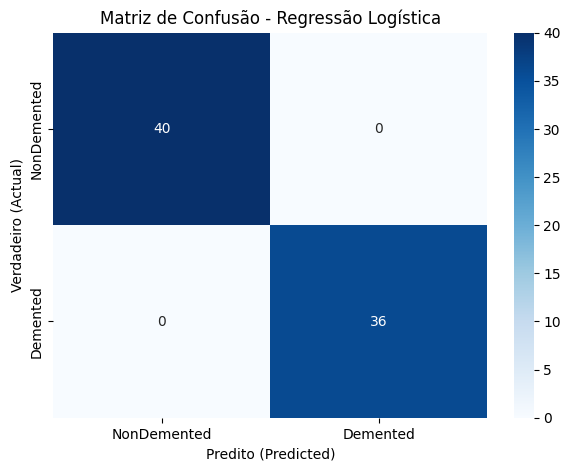

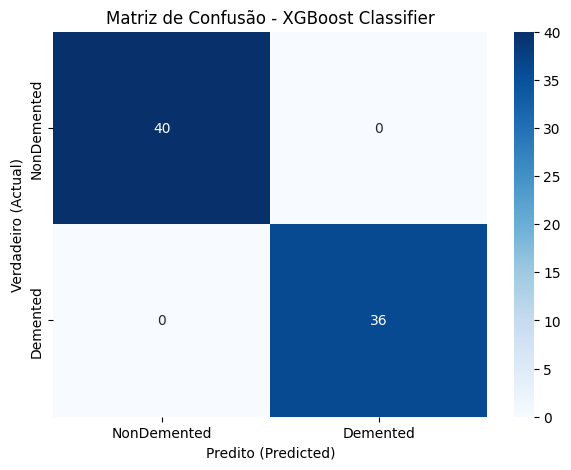

In [4]:
print("Classificação (Demented vs NonDemented)")

target_t1 = 'Group'
cat_features_t1 = ['M/F'] 

# 'Hand' é removido pois é quase sempre 'R'
drop_cols_t1 = ['Subject ID', 'MRI ID', 'Hand', target_t1] 

num_features_t1 = [
    col for col in df_train.columns 
    if col not in cat_features_t1 + drop_cols_t1 and 
    df_train[col].dtype in ['int64', 'float64']
]

print(f"Tarefa 1 usando {len(num_features_t1)} features numéricas e {len(cat_features_t1)} categóricas.")

# Criar Pipeline de Pré-processamento
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # MMSE, SES etc. podem ter NaNs
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_t1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features_t1),
        ('cat', categorical_transformer, cat_features_t1)
    ],
    remainder='drop' # Ignora colunas não especificadas (como 'Subject ID')
)

# Preparar X e y
X_train_t1 = preprocessor_t1.fit_transform(df_train)
X_val_t1 = preprocessor_t1.transform(df_val)
X_test_t1 = preprocessor_t1.transform(df_test)

y_train_t1 = df_train[target_t1].map({'Demented': 1, 'NonDemented': 0})
y_val_t1 = df_val[target_t1].map({'Demented': 1, 'NonDemented': 0})
y_test_t1 = df_test[target_t1].map({'Demented': 1, 'NonDemented': 0})

# Modelo 1: Regressão Logística
print("\n--- Treinando Modelo: Regressão Logística ---")
# Usar o conjunto de validação para achar o melhor hiperparâmetro C
best_score = 0
best_C = 0.1
print("Buscando melhor C (hiperparâmetro) no conjunto de validação...")
for C in [0.01, 0.1, 1.0, 10.0]:
    model_lr = LogisticRegression(C=C, random_state=42, max_iter=1000, solver='liblinear')
    model_lr.fit(X_train_t1, y_train_t1)
    score = model_lr.score(X_val_t1, y_val_t1)
    if score > best_score:
        best_score = score
        best_C = C

print(f"Melhor C encontrado: {best_C} (Score de Validação: {best_score:.4f})")
print("Treinando modelo final com Treino+Validação...")
# Treina o modelo final com o melhor C nos dados de treino + validação
X_train_val_t1 = np.vstack((X_train_t1, X_val_t1))
y_train_val_t1 = np.concatenate((y_train_t1, y_val_t1))

final_model_lr = LogisticRegression(C=best_C, random_state=42, max_iter=1000, solver='liblinear')
final_model_lr.fit(X_train_val_t1, y_train_val_t1)

# Avalia no conjunto de Teste
y_pred_lr_t1 = final_model_lr.predict(X_test_t1)
print("\n--- Métricas (Regressão Logística) no Conjunto de Teste ---")
print(f"Acurácia:     {accuracy_score(y_test_t1, y_pred_lr_t1):.4f}")
print(f"Sensibilidade: {recall_score(y_test_t1, y_pred_lr_t1):.4f} (Recall - Taxa de 'Demented' corretos)")
print(f"Especificidade: {specificity_score(y_test_t1, y_pred_lr_t1):.4f} (Taxa de 'NonDemented' corretos)")
plot_confusion_matrix(y_test_t1, y_pred_lr_t1, "Matriz de Confusão - Regressão Logística", "out/cm_lr")

# Modelo 2: XGBoost Classifier
# Usamos o conjunto de validação para early stopping
model_xgb_c = XGBClassifier(random_state=42, eval_metric='logloss', early_stopping_rounds=10)
model_xgb_c.fit(X_train_t1, y_train_t1,
                eval_set=[(X_val_t1, y_val_t1)],
                verbose=False)

# Avalia no conjunto de Teste
y_pred_xgb_t1 = model_xgb_c.predict(X_test_t1)
print("\n--- Métricas (XGBoost Classifier) no Conjunto de Teste ---")
print(f"Acurácia:     {accuracy_score(y_test_t1, y_pred_xgb_t1):.4f}")
print(f"Sensibilidade: {recall_score(y_test_t1, y_pred_xgb_t1):.4f} (Recall)")
print(f"Especificidade: {specificity_score(y_test_t1, y_pred_xgb_t1):.4f} (Specificity)")
plot_confusion_matrix(y_test_t1, y_pred_xgb_t1, "Matriz de Confusão - XGBoost Classifier", "out/cm_xgb_c")

Regressão (Estimar Idade)
Tarefa 2 usando 23 features numéricas e 1 categóricas.

--- Treinando Modelo: Regressão Linear ---

--- Métricas (Regressão Linear) no Conjunto de Teste ---
R² Score: 0.1570
MAE (Erro Médio Absoluto): 5.5594 anos
Gráfico de predição de idade salvo em out/scatter_lr_age.png

--- Métricas (XGBoost Regressor) no Conjunto de Teste ---
R² Score: 0.3210
MAE (Erro Médio Absoluto): 4.9646 anos
Gráfico de predição de idade salvo em out/scatter_xgb_age.png


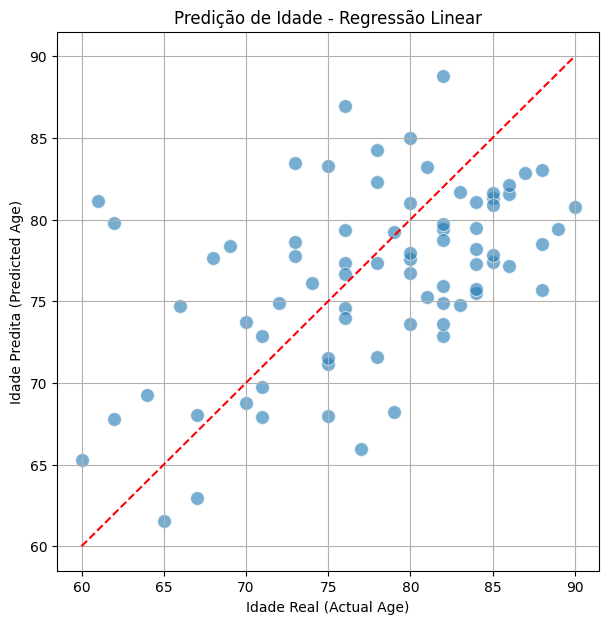

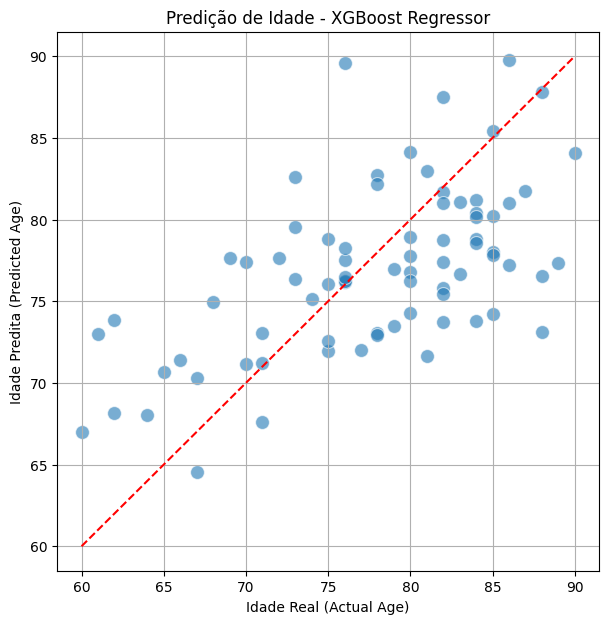

In [5]:
print("Regressão (Estimar Idade)")

# Features (X): Inclui 'Group' e outros dados
# Target (y): 'Age'
target_t2 = 'Age'

# Mapeia 'Group' para ser uma feature numérica
df_train['Group_mapped'] = df_train['Group'].map({'Demented': 1, 'NonDemented': 0})
df_val['Group_mapped'] = df_val['Group'].map({'Demented': 1, 'NonDemented': 0})
df_test['Group_mapped'] = df_test['Group'].map({'Demented': 1, 'NonDemented': 0})

cat_features_t2 = ['M/F']
drop_cols_t2 = ['Subject ID', 'MRI ID', 'Hand', 'Group', target_t2]

num_features_t2 = [
    col for col in df_train.columns 
    if col not in cat_features_t2 + drop_cols_t2 and 
    df_train[col].dtype in ['int64', 'float64']
]

if 'Group_mapped' not in num_features_t2:
    num_features_t2.append('Group_mapped')

print(f"Tarefa 2 usando {len(num_features_t2)} features numéricas e {len(cat_features_t2)} categóricas.")

# Criar Pipeline de Pré-processamento
preprocessor_t2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features_t2), # Lista de features T2
        ('cat', categorical_transformer, cat_features_t2) # Lista de features T2
    ],
    remainder='drop'
)

# Preparar X e y
X_train_t2 = preprocessor_t2.fit_transform(df_train)
X_val_t2 = preprocessor_t2.transform(df_val)
X_test_t2 = preprocessor_t2.transform(df_test)

y_train_t2 = df_train[target_t2]
y_val_t2 = df_val[target_t2]
y_test_t2 = df_test[target_t2]

# Modelo 1: Regressão Linear
print("\n--- Treinando Modelo: Regressão Linear ---")
# Não há hiperparâmetros complexos, treinamos direto
model_lr_r = LinearRegression()
model_lr_r.fit(X_train_t2, y_train_t2)

# Avalia no conjunto de Teste
y_pred_lr_t2 = model_lr_r.predict(X_test_t2)
print("\n--- Métricas (Regressão Linear) no Conjunto de Teste ---")
print(f"R² Score: {r2_score(y_test_t2, y_pred_lr_t2):.4f}")
print(f"MAE (Erro Médio Absoluto): {mean_absolute_error(y_test_t2, y_pred_lr_t2):.4f} anos")
plot_age_scatterplot(y_test_t2, y_pred_lr_t2, "Predição de Idade - Regressão Linear", "out/scatter_lr_age")

# Modelo 2: XGBoost Regressor
# Conjunto de validação para early stopping
model_xgb_r = XGBRegressor(random_state=42, eval_metric='rmse', early_stopping_rounds=10)
model_xgb_r.fit(X_train_t2, y_train_t2,
                eval_set=[(X_val_t2, y_val_t2)],
                verbose=False)

# Avalia no conjunto de Teste
y_pred_xgb_t2 = model_xgb_r.predict(X_test_t2)
print("\n--- Métricas (XGBoost Regressor) no Conjunto de Teste ---")
print(f"R² Score: {r2_score(y_test_t2, y_pred_xgb_t2):.4f}")
print(f"MAE (Erro Médio Absoluto): {mean_absolute_error(y_test_t2, y_pred_xgb_t2):.4f} anos")
plot_age_scatterplot(y_test_t2, y_pred_xgb_t2, "Predição de Idade - XGBoost Regressor", "out/scatter_xgb_age")